# Homework 7: Sentiment Classification with Pre-trained and Re-trained GloVe Embeddings

## Due: Midnight on October 19th @ Midnight (with 2-hour grace period) and worth 85 points.

In this notebook, we’ll continue with the investigation of text classification using "`Bag of Embeddings`" models and the IMDB movie review dataset.
We'll focus on unfrozen embeddings, which refine the embedding space based on your dataset.

You'll do three problems:

* **Problem One:** Build a baseline model with unfrozen embeddings and experiment with architectural and training adjustments to improve performance.
* **Problem Two:** Investigate how increasing the maximum message length and vocabulary size affects model accuracy and generalization.
* **Problem Three:** Examine the impact of changing the embedding dimension on model performance.


In each problem, you'll report your best validation accuracy and reflect on what you have learned.

        https://en.wikipedia.org/wiki/GloVe

        GloVe, coined from Global Vectors, is a model for distributed word representation. The model is an unsupervised learning algorithm for obtaining vector representations of words. This is achieved by mapping words into a meaningful space where the distance between words is related to semantic similarity.[1] Training is performed on aggregated global word-word co-occurrence statistics from a corpus, and the resulting representations showcase interesting linear substructures of the word vector space. As log-bilinear regression model for unsupervised learning of word representations, it combines the features of two model families, namely the global matrix factorization and local context window methods.

        It was developed as an open-source project at Stanford University[2] and launched in 2014. It was designed as a competitor to word2vec, and the original paper noted multiple improvements of GloVe over word2vec. As of 2022, both approaches are outdated, and Transformer-based models, such as BERT, which add multiple neural-network attention layers on top of a word embedding model similar to Word2vec, have come to be regarded as the state of the art in NLP.[3]

## Useful Imports

In [68]:
# %pip install tensorflow

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time

from collections import Counter
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, Input, Sequential
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,LearningRateScheduler,ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.layers import LayerNormalization, MaxPooling2D,Dropout,GlobalAveragePooling2D,Dense
from tensorflow.keras.layers import Conv2D,BatchNormalization,Activation,GlobalMaxPooling1D, Flatten
from sklearn.model_selection import StratifiedShuffleSplit


# Reproducibility
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

# utility code
from datetime import datetime

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

'''  How to time your code
# start timer
start_time = time.time()

<your code here>

# Record end time and print execution time
print(f"Execution Time: " + format_time(time.time()-start_time))
'''

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:

sns.set_theme(font_scale=0.9)
# plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize']    = 10
plt.rcParams['axes.labelsize']    = 8
plt.rcParams['lines.linewidth']   = 2
plt.rcParams['lines.markersize']  = 4
plt.rcParams['axes.edgecolor']    = 'gray'
plt.rcParams['xtick.color']       = 'gray'
plt.rcParams['ytick.color']       = 'gray'
plt.rcParams['xtick.color']       = 'gray'
plt.rcParams['ytick.color']       = 'gray'
plt.rcParams['ytick.labelsize']   = 8
plt.rcParams['xtick.labelsize']   = 8

## Utility functions

- Call `print_results()` to see listing of all results logged so far
- We've also added  `

### plot_learning_curves

In [70]:
def plot_learning_curves(hist, title, verbose = True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()


###  training and testing

**Assumptions**:   
- Early stopping is default, add other callbacks as needed
- Uses "binary_crossentropy" for binary classification task.
- Assumes `X_train,y_train,X_test,y_test` already defined, will access them as global variables.
- If `X_val` and `y_val` defined, will use those, else assumes `validation_split = 0.2` in `fit`


**Note:** See the end of the notebook for results and parameter settings.

In [71]:
def train_and_test(model,
                   title         = "Learning Curves",
                   epochs        = 200,                   # Just needs to be bigger than early stopping point
                   optimizer     = "Adam",
                   lr_schedule   = 1e-3,                  # Adam defaults
                   clipnorm      = None,
                   batch_size    = 128,
                   loss          = "binary_crossentropy",
                   metrics       = ["accuracy"],
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   use_reduce_on_plateau = False,           # NEW FLAG
                   rlrop_patience = 5,                      # NEW PARAMETER
                   rlrop_factor  = 0.5,                      # NEW PARAMETER
                   verbose       = 0,
                   return_history = False
                  ):


    print(f"\n{title}\n")

    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule,clipnorm=clipnorm)
    else:
        opt = optimizer

    #Compiling the model
    model.compile(optimizer = opt,
                  loss      = loss,
                  metrics   = metrics
                 )

# --- CALLBACK ASSEMBLY ---
    cbs = []

    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor              = 'val_loss',
            patience             = patience,
            min_delta            = min_delta,
            restore_best_weights = True,               # this will mean that the model which produced the smallest validation loss will be returned
            verbose              = verbose
        )
        cbs.append(early_stop)

    if use_reduce_on_plateau:
        reduce_lr = ReduceLROnPlateau(
            monitor   = 'val_loss',    # Metric to monitor
            factor    = rlrop_factor,  # Factor by which LR will be reduced (e.g., 0.5)
            patience  = rlrop_patience, # Number of epochs with no improvement
            min_delta = min_delta,     # Only reduce for significant stagnation
            cooldown  = 0,
            min_lr    = 1e-8,
            verbose   = 1,
        )
        cbs.append(reduce_lr)

    cbs.extend(callbacks)

    # start timer
    start = time.time()

    # Fit the model with early stopping
    # If X_val defined, then  use it, else assume val is split from train

    if 'X_val' in globals():
        history = model.fit(X_train, y_train,
                            epochs          = epochs,
                            batch_size      = batch_size,
                            validation_data = (X_val, y_val),
                            callbacks       = cbs,
                            verbose         = verbose
                           )
    else:
        history = model.fit(X_train, y_train,
                            epochs            = epochs,
                            batch_size        = batch_size,
                            validation_split  = 0.2,
                            callbacks         = cbs,
                            verbose           = verbose
                           )

    # Plot training history
    plot_learning_curves(history, title=title)

    # Find epoch with minimum validation loss
    min_val_epoch = np.argmin(history.history['val_loss'])

    # Retrieve the values at that epoch
    min_val_loss = history.history['val_loss'][min_val_epoch]

    # Get corresponding validation accuracy at that epoch
    val_acc_at_min_loss = history.history['val_accuracy'][min_val_epoch]

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    end             = time.time()
    execution_time  = format_hms(end - start)
    print(f"\nExecution Time: " + execution_time)

    # Print out results

    print(f"\nFinal Train Loss:            {history.history['loss'][-1]:.4f}")
    print(f"Final Train Acc:        {history.history['accuracy'][-1]:.4f}")
    print(f"Final Val Loss:          {history.history['val_loss'][-1]:.4f}")
    print(f"Final Val Acc:      {history.history['val_accuracy'][-1]:.4f}")
    print(f"Min Val Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Val Acc @ Min Loss: {val_acc_at_min_loss:.4f}")

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Acc: {test_accuracy:.4f}")

    print(f"\nVal-Test Acc Gap: {abs(val_acc_at_min_loss - test_accuracy):.6f}")

    # Store accuracy in results
    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

    # Store all information about run in parameter_settings

    global parameter_settings
    entry = {
        "title": title,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        'execution_time': execution_time,
        "epochs": int(epochs),
        "optimizer": optimizer,
        "lr_schedule": lr_schedule,
        "clipnorm": clipnorm,
        "loss": loss,
        "batch_size": batch_size,
        "use_early_stopping": use_early_stopping,
        "patience": patience,
        "min_delta": min_delta,
        # Add RLR-specific parameters to the log for easy comparison
        "use_reduce_on_plateau": use_reduce_on_plateau,
        "rlrop_patience": rlrop_patience if use_reduce_on_plateau else None,
        "rlrop_factor": rlrop_factor if use_reduce_on_plateau else None,
        "callbacks": _summarize_callbacks(callbacks),
        "Final Train Loss" : history.history['loss'][-1],
        "Final Train Acc" : history.history['accuracy'][-1],
        "Final Val Loss" : history.history['val_loss'][-1],
        "Final Val Acc" : history.history['val_accuracy'][-1],
        "Min Val Loss" : min_val_loss,
        "Min Val Loss Epoch" : min_val_epoch,
        "Val Acc @ Min Loss" : val_acc_at_min_loss,
        "Test Loss" : test_loss,
        "Test Acc" : test_accuracy,
        "Val-Test Acc Gap:" : abs(val_acc_at_min_loss - test_accuracy)
    }
    parameter_settings.setdefault(title, []).append(entry)

    if return_history:
        return history
    # Only return the dictionary if return_history is False AND the user
    # explicitly assigns the result to a variable. Otherwise, return None
    # to avoid implicit printing in Colab.
    # Return parameter_settings if return_history is True to
    # keep the historical behavior for the rest of the file.
    return parameter_settings if return_history else None




def _summarize_callbacks(cbs):
    if cbs is None:
        return None
    out = []
    for cb in cbs:
        name = getattr(cb, "__class__", type(cb)).__name__
        info = {"class": name}
        # grab a few common attributes if present
        for attr in ("monitor", "mode", "patience", "min_delta",
                     "factor", "min_lr", "verbose", "cooldown"):
            if hasattr(cb, attr):
                info[attr] = getattr(cb, attr)
        out.append(info)
    return out

results             = {}
parameter_settings  = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key      = lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse  = True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

In [72]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-5,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

#  put in the callbacks list:

#    train_and_test(model, title="Learning Curves",callbacks=[reduce_lr])


### run_new_from_best_unfrozen_exp

In [73]:
def run_new_from_best_unfrozen_exp(new_vocab_size,
                                   new_max_length,
                                   title_suffix,
                                   new_embedding_dimension=100,
                                   lr=1e-3):
    """
    Loads, preprocesses data with new parameters, generates the embedding matrix,
    and trains the P1 best model architecture.
    """
    global embedding_matrix, X_train, X_test, y_train, y_test
    global training_vocabulary_size, max_text_length, embedding_dimension
    global embeddings_index  # Will be re-loaded

    training_vocabulary_size = new_vocab_size
    max_text_length = new_max_length
    embedding_dimension = new_embedding_dimension
    print(f"\n--- Loading Data: V={training_vocabulary_size}, L={max_text_length}, D={embedding_dimension}d ---")

    # Load and Preprocess Data with NEW PARAMS
    print(f"\n--- Loading Data for {title_suffix}: V={training_vocabulary_size}, L={max_text_length} ---")
    (X_tr, y_tr), (X_te, y_te) = imdb.load_data(num_words=training_vocabulary_size)

    X = np.concatenate([X_tr, X_te], axis=0)
    y = np.concatenate([y_tr, y_te], axis=0)

    # Note: Using the global train_test_split variables from the notebook's prelude
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train = pad_sequences(X_train, maxlen=max_text_length, padding='post', truncating='post')
    X_test = pad_sequences(X_test, maxlen=max_text_length, padding='post', truncating='post')

    print(f"Padded X_train shape: {X_train.shape}")

    # --- 3. Re-Load GloVe Vectors for New Dimension ---
    glove_path = glove_file_names.get(embedding_dimension)
    if glove_path is None or not glove_path.exists():
        print(f"ERROR: GloVe file not found for dimension {embedding_dimension}d. Using zero-initialized matrix.")
        embeddings_index = {}
    else:
        print(f"Loading GloVe embeddings from: {glove_path}")
        embeddings_index = {}
        start_time = time.time()
        with glove_path.open(encoding='utf8') as f:
            for line in f:
                word, *vec = line.split()
                embeddings_index[word] = np.asarray(vec, dtype='float32')
        print(f"Loaded {len(embeddings_index):,} word vectors in {format_hms(time.time() - start_time)}.")

    # --- 4. Build Embedding Matrix with NEW VOCAB & DIMENSION ---
    word_index = imdb.get_word_index()
    embedding_matrix = np.zeros((training_vocabulary_size, embedding_dimension))

    found_words = 0
    for word, raw_idx in word_index.items():
        idx = raw_idx + 3
        if idx < training_vocabulary_size:
            vec = embeddings_index.get(word)
            if vec is not None:
                embedding_matrix[idx] = vec
                found_words += 1

    print(f"Embedding Matrix shape: {embedding_matrix.shape} (Words covered: {found_words:,})")

    # --- 5. Define and Train Model (P1 Best Architecture: Unfrozen Baseline) ---
    model = Sequential([
        Input(shape=(max_text_length,), dtype='int32'),
        Embedding(
            input_dim=training_vocabulary_size,
            output_dim=embedding_dimension,
            weights=[embedding_matrix],
            mask_zero=True,
            trainable=True
        ),
        GlobalAveragePooling1D(),
        Dense(1, activation='sigmoid')
    ])

    title = f"{title_suffix}_v{training_vocabulary_size}_l{max_text_length}_d{embedding_dimension}d_lr{lr:.0e}"
    train_and_test(model, lr_schedule=lr, title=title, return_history=True)

    # Return new entry for summary table
    return globals()['parameter_settings'].get(title)[-1]


## Prelude:  A little EDA: Distribution of review lengths and coverage by max vocabulary size

You will use this to think about where the set parameters for maximum review length and the maximum number of unique tokens to use.


Total unique words in Keras IMDB word_index (corpus-wide): 88,584
Num training reviews: 25,000
Max length: 2,494 tokens
Mean length: 238.7 tokens
Median length: 178 tokens
90th percentile: 467 tokens
95th percentile: 610 tokens
99th percentile: 926 tokens


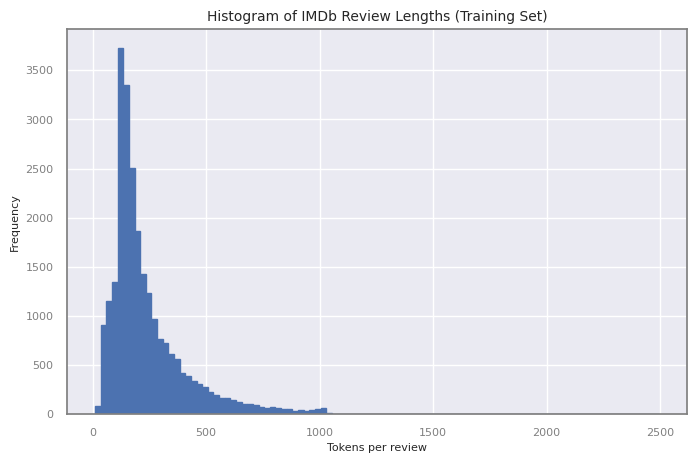


Unique word types in TRAIN (id >= 3): 88,583
Total word tokens in TRAIN (id >= 3): 5,942,840

Coverage metrics by candidate vocab size (TRAIN split):
training_vocabulary_size= 2,000 | coverage= 82.84% | OOV= 17.16% | types kept=  1,997 | tokens kept= 4,922,766
training_vocabulary_size= 5,000 | coverage= 90.03% | OOV=  9.97% | types kept=  4,997 | tokens kept= 5,350,551
training_vocabulary_size=10,000 | coverage= 94.25% | OOV=  5.75% | types kept=  9,997 | tokens kept= 5,601,261
training_vocabulary_size=20,000 | coverage= 97.22% | OOV=  2.78% | types kept= 19,997 | tokens kept= 5,777,376
training_vocabulary_size=30,000 | coverage= 98.37% | OOV=  1.63% | types kept= 29,997 | tokens kept= 5,846,141
training_vocabulary_size=50,000 | coverage= 99.32% | OOV=  0.68% | types kept= 49,997 | tokens kept= 5,902,246
training_vocabulary_size=70,000 | coverage= 99.69% | OOV=  0.31% | types kept= 69,997 | tokens kept= 5,924,254
training_vocabulary_size=88,584 | coverage=100.00% | OOV=  0.00% | types

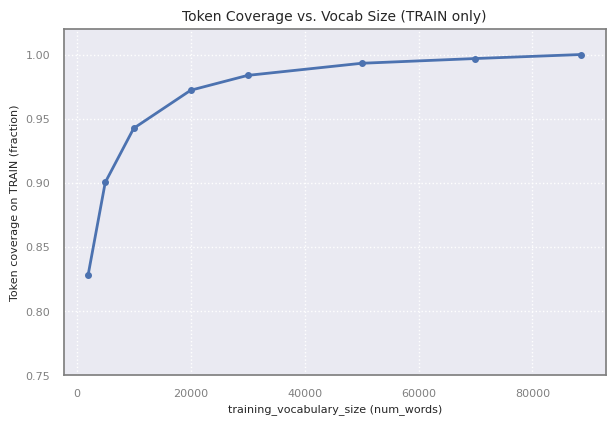

In [74]:
# IMDB vocab & length stats + coverage table + single coverage plot



# ---------------------------------------
# Load IMDB with NO cap (so we can measure coverage fairly)
# ---------------------------------------
(X_tr, y_tr), _ = imdb.load_data()

# ---------------------------------------
# 1) Global vocab stats (from Keras word_index)
# ---------------------------------------
word_index                = imdb.get_word_index()  # mapping: word -> rank (lower rank = more frequent)
total_unique_words_corpus = len(word_index)  # across the full IMDB corpus Keras ships
print(f"Total unique words in Keras IMDB word_index (corpus-wide): {total_unique_words_corpus:,}")

# ---------------------------------------
# 2) Training review length stats + histogram (students pick max_text_length)
# ---------------------------------------
lengths = np.fromiter((len(r) for r in X_tr), dtype=np.int32)
print(f"Num training reviews: {len(lengths):,}")
print(f"Max length: {lengths.max():,} tokens")
print(f"Mean length: {lengths.mean():.1f} tokens")
print(f"Median length: {np.median(lengths):.0f} tokens")
for q in (90, 95, 99):
    print(f"{q}th percentile: {int(np.percentile(lengths, q))} tokens")

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=100, edgecolor='b')
plt.title("Histogram of IMDb Review Lengths (Training Set)")
plt.xlabel("Tokens per review")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------------
# 3) Training-only frequency counts for real words (ids >= 3)
#    IMDB ID conventions: 0=<PAD>, 1=<START>, 2=<OOV>, >=3 actual words
# ---------------------------------------
def iter_tokens(seqs):
    for s in seqs:
        for t in s:
            yield t

train_counts = Counter(t for t in iter_tokens(X_tr) if t >= 3)

# Frequency list (descending) and cumulative token coverage
freqs                     = np.array(sorted(train_counts.values(), reverse=True), dtype=np.int64)
cum_tokens                = np.cumsum(freqs)
total_tokens_train_words  = int(cum_tokens[-1])
num_unique_words_train    = int(len(freqs))

print(f"\nUnique word types in TRAIN (id >= 3): {num_unique_words_train:,}")
print(f"Total word tokens in TRAIN (id >= 3): {total_tokens_train_words:,}")

# ---------------------------------------
# 4) Coverage helper for a given num_words cap (Keras convention)
#    Valid word ids are [3, num_words_cap-1] → ranks [1 .. num_words_cap-3]
# ---------------------------------------
def coverage_for_cap(num_words_cap: int):
    kept_types    = max(0, min(num_words_cap - 3, num_unique_words_train))
    kept_tokens   = int(cum_tokens[kept_types - 1]) if kept_types > 0 else 0
    oov_tokens    = total_tokens_train_words - kept_tokens
    coverage      = kept_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    oov_share     = oov_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    return dict(
        cap         = num_words_cap,
        kept_tokens = kept_tokens,
        kept_types  = kept_types,
        coverage    = coverage,
        oov_share   = oov_share
    )

# ---------------------------------------
# 5) Candidate vocab sizes: ASCII table + single coverage plot
# ---------------------------------------
candidate_caps = [2_000, 5_000, 10_000, 20_000, 30_000, 50_000,70_000,88_584]  # students can edit
rows = [coverage_for_cap(k) for k in candidate_caps]

print("\nCoverage metrics by candidate vocab size (TRAIN split):")
for r in rows:
    print(f"training_vocabulary_size={r['cap']:>6,} | coverage={r['coverage']*100:6.2f}% | "
          f"OOV={r['oov_share']*100:6.2f}% | types kept={r['kept_types']:>7,} | tokens kept={r['kept_tokens']:>10,}")

plt.figure(figsize=(7, 4.5))
plt.plot(candidate_caps, [r['coverage'] for r in rows], marker='o')
plt.xlabel("training_vocabulary_size (num_words)")
plt.ylabel("Token coverage on TRAIN (fraction)")
plt.title("Token Coverage vs. Vocab Size (TRAIN only)")
plt.grid(True, linestyle=":")
plt.ylim(0.75, 1.02)
plt.show()


### Load and preprocess dataset

Here is where you can set the
- `training_vocabulary_size` and
- `max_text_length`

In [75]:
# Load and preprocess dataset into padded sequences of token IDs

training_vocabulary_size = 50_000               # <-----
max_text_length          = 500                  # <-----

(X_tr, y_tr), (X_te, y_te) = imdb.load_data( num_words = training_vocabulary_size )

X  = np.concatenate([X_tr, X_te], axis=0)
y  = np.concatenate([y_tr, y_te], axis=0)

# 80 / 20 stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size     = 0.2,
    random_state  = random_seed,
    stratify      = y
)



X_train = pad_sequences(
    X_train,
    maxlen      = max_text_length,
    padding     = 'post',
    truncating  = 'post'
)

X_test = pad_sequences(
    X_test,
    maxlen      = max_text_length,
    padding     = 'post',
    truncating  = 'post'
)


X_train.shape,X_test.shape

((40000, 500), (10000, 500))

### Build the embedding matrix

Here is where you can set
- `embedding_dimension`


In [76]:
DRIVE_BASE_PATH = Path('/content/drive/MyDrive/DX703/glove_data/glove.6B/')

# Dictionary of embedding files hosted on Google Drive (using local paths now)
glove_file_names = {
    50: DRIVE_BASE_PATH / "glove.6B.50d.txt",
    100: DRIVE_BASE_PATH / "glove.6B.100d.txt",
    200: DRIVE_BASE_PATH / "glove.6B.200d.txt",
    300: DRIVE_BASE_PATH / "glove.6B.300d.txt"
}

embedding_dimension = 100                     # <-----

print(f"Attempting to load GloVe vectors of size: {embedding_dimension}d")

# Get the correct path for the selected dimension
glove_path = glove_file_names.get(embedding_dimension)

if glove_path is None:
    raise ValueError(f"No GloVe path found for dimension {embedding_dimension}")

if not glove_path.exists():
    raise FileNotFoundError(f"GloVe file not found at: {glove_path}. Check your mounting and folder path.")

print(f"Loading GloVe embeddings from: {glove_path}")

Attempting to load GloVe vectors of size: 100d
Loading GloVe embeddings from: /content/drive/MyDrive/DX703/glove_data/glove.6B/glove.6B.100d.txt


In [77]:
#  Build embedding matrix

embeddings_index  = {}
start_time        = time.time()

# Load the GloVe vectors
with glove_path.open(encoding='utf8') as f:
    for line in f:
        # Split the line into the word and its vector components
        word, *vec = line.split()
        # Convert vector components to a numpy array of float32
        embeddings_index[word] = np.asarray(vec, dtype='float32')

print(f"Loaded {len(embeddings_index):,} word vectors.")
print(f"Load Time: " + time.strftime("%M:%S", time.gmtime(time.time() - start_time)))


# Get the word index mapping from Keras IMDB dataset
word_index = imdb.get_word_index()

# Initialize the embedding matrix (size: vocab_size x embedding_dimension)
embedding_matrix  = np.zeros((training_vocabulary_size, embedding_dimension))
oov_count         = 0
found_words       = 0

# Populate the embedding matrix
for word, raw_idx in word_index.items():
    # IMDB tokens are 1-indexed, but Keras adds 3 reserved indices:
    # 0 = <PAD>, 1 = <START>, 2 = <OOV> (Out-Of-Vocabulary)
    # The actual word index starts at 3.
    idx = raw_idx + 3

    if idx < training_vocabulary_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec
            found_words += 1
        else:
            # Word is in IMDB vocab but not in GloVe
            # OOV words will remain all zeros (random initialization is often
            # better, but zero is simple and common for pre-trained OOV).
            oov_count += 1

print(f"Words in Keras vocab covered by GloVe: {found_words:,} / {training_vocabulary_size:,}")
print(f"Words in Keras vocab NOT covered by GloVe (OOV): {oov_count:,}")


Loaded 400,000 word vectors.
Load Time: 00:08
Words in Keras vocab covered by GloVe: 42,330 / 50,000
Words in Keras vocab NOT covered by GloVe (OOV): 7,666


### Baseline Model from the Coding Notebook


model_baseline (frozen)



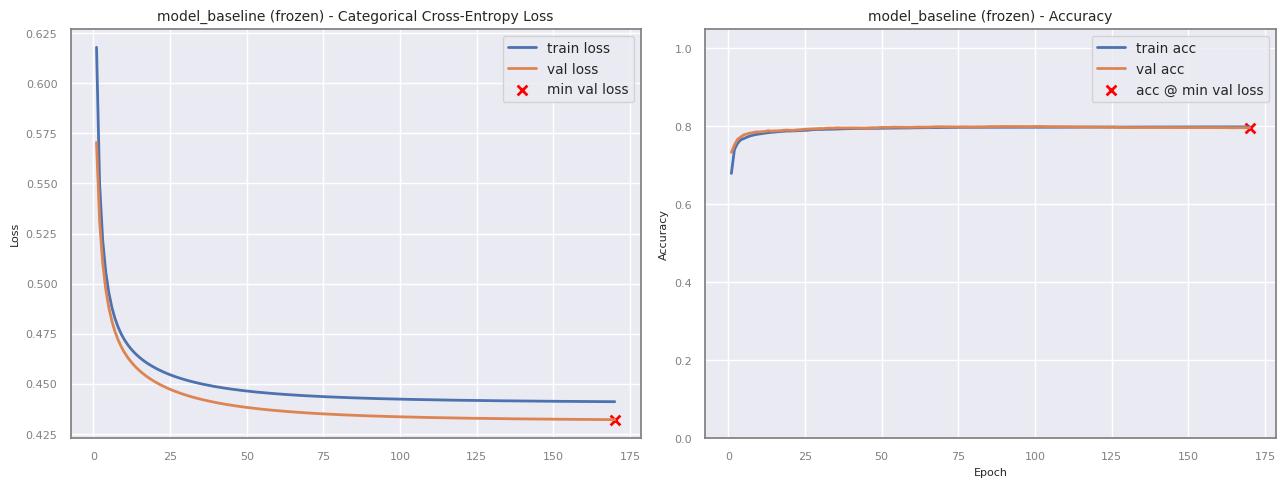


Execution Time: 00:01:48

Final Train Loss:            0.4411
Final Train Acc:        0.7983
Final Val Loss:          0.4321
Final Val Acc:      0.7961
Min Val Loss:        0.4321 (Epoch 170)
Val Acc @ Min Loss: 0.7961

Test Loss: 0.4331
Test Acc: 0.8076

Val-Test Acc Gap: 0.011475


In [78]:

model_baseline_frozen = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),   # each sample is a sequence of max_text_length integers, e.g., 500
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,                      # ignore <PAD> in pooling -- this makes a huge difference in training speed!
        trainable  = False                      # freeze or unfreeze embedding weights
    ),
    GlobalAveragePooling1D(),                        # take average along each dimension
    Dense(1, activation='sigmoid')
])


train_and_test(model_baseline_frozen,  lr_schedule=1e-2, title="model_baseline (frozen)")

#### End of Template Code from Coding Notebook

## Problem One: Baseline with Unfrozen Embeddings

**ToDo:**

1. Establish a baseline for unfrozen embeddings by running the baseline model but with `trainable = True` to retrain the embeddings as it trains on the the classification task. You will use retrainable embeddings throughout the homework.

2. Now run 2-3 experiments to try to improve this baseline:

    - Consider adding a Dense layer between the global average pooling and the output layer, with
        - Your choice of size
        - Your choice of L2 regularizatio (or not)
        - Your choice of dropout (or not)
3. As needed, tweak the learning rate (try `1e-4`) and try it with or without Reduce on Plateau (you can tweak the parameters there as well)
4. Define your best model for unfrozen embeddings based on these experiments (you will use it in the remaining two problems)
5. Answer the graded questions

**Note:** Generally, you will need a lower learning rate for retrainable embeddings.

### model_1_base_unfr_lr001


1_base_unfr_lr001



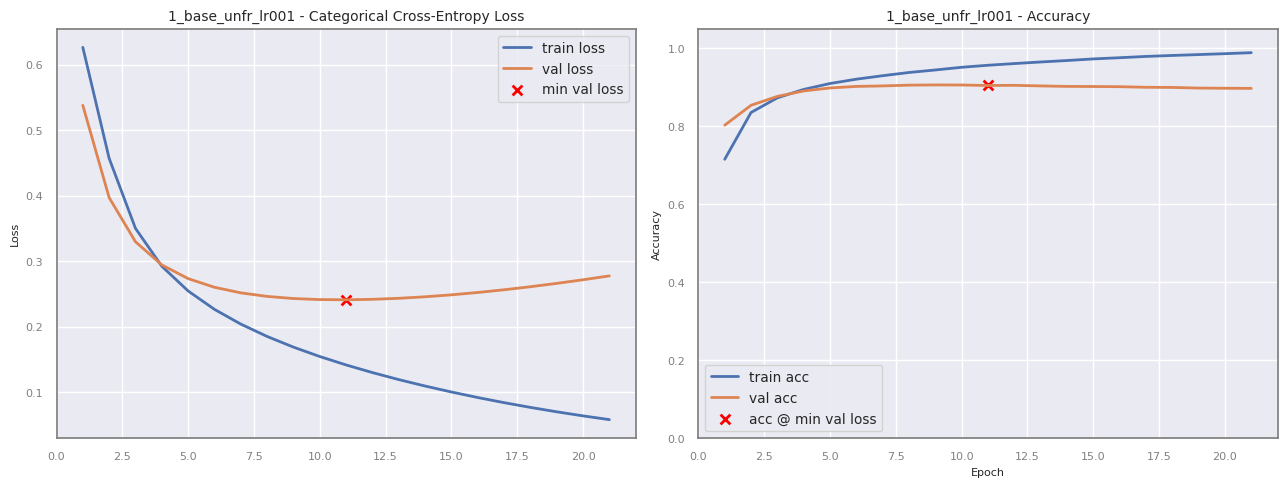


Execution Time: 00:00:21

Final Train Loss:            0.0585
Final Train Acc:        0.9886
Final Val Loss:          0.2777
Final Val Acc:      0.8971
Min Val Loss:        0.2413 (Epoch 11)
Val Acc @ Min Loss: 0.9045

Test Loss: 0.2528
Test Acc: 0.9002

Val-Test Acc Gap: 0.004300


In [79]:
model_1_base_unfr_lr001 = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),   # each sample is a sequence of max_text_length integers, e.g., 500
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,                      # ignore <PAD> in pooling -- this makes a huge difference in training speed!
        trainable  = True                      # trainable embeddings
    ),
    GlobalAveragePooling1D(),                        # take average along each dimension
    Dense(1, activation = 'sigmoid')
])


results_1_base_unfr_lr001 = train_and_test(model_1_base_unfr_lr001,
                                           lr_schedule    = 1e-3,
                                           title          = "1_base_unfr_lr001",
                                           return_history = True)

In [80]:
results_1_base_unfr_lr001_df = pd.DataFrame(parameter_settings.get("1_base_unfr_lr001"))
results_1_base_unfr_lr001_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,1_base_unfr_lr001,2025-10-17T03:53:39,00:00:21,200,Adam,0.001,None,binary_crossentropy,128,True,...,0.058542,0.988594,0.277739,0.897125,0.241294,10,0.9045,0.252793,0.9002,0.0043


### model_1_2_l2reg_lr0001

In [81]:
# Using a dense layer of size 16 and L2 regularization of 1e-3.
l2_reg_strength = 1e-3

model_1_2_l2reg_lr0001 = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,
        trainable  = True
    ),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu', kernel_regularizer = l2(l2_reg_strength)), # New dense layer with L2
    Dense(1, activation = 'sigmoid')
])


 Experiment 1.2: Dense Layer + L2 Reg (LR=1e-4)

1_2_l2_reg_lr0001



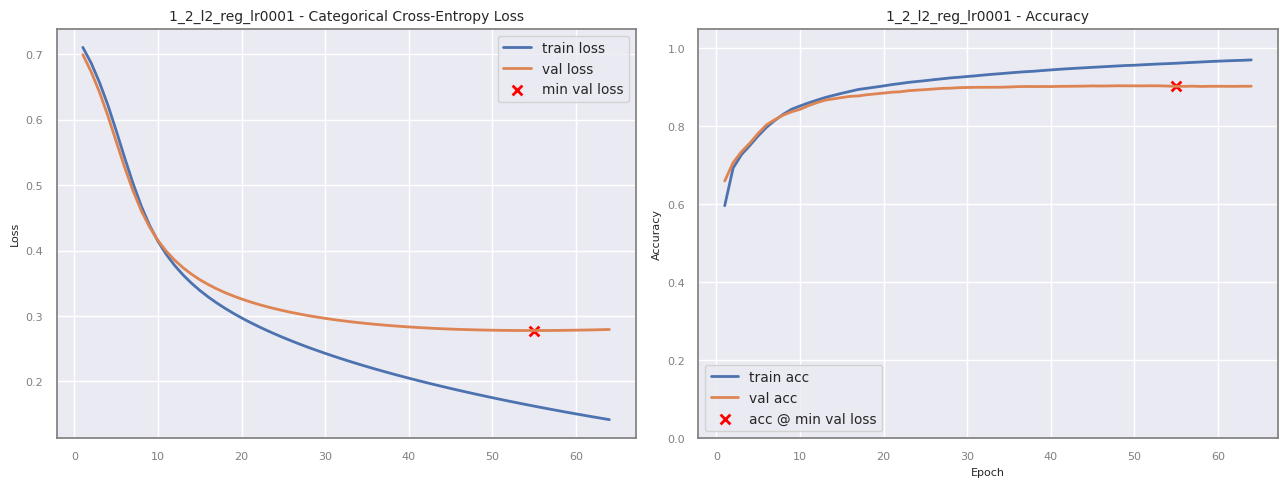


Execution Time: 00:01:01

Final Train Loss:            0.1415
Final Train Acc:        0.9700
Final Val Loss:          0.2793
Final Val Acc:      0.9026
Min Val Loss:        0.2777 (Epoch 55)
Val Acc @ Min Loss: 0.9024

Test Loss: 0.2890
Test Acc: 0.9004

Val-Test Acc Gap: 0.001975


In [82]:
print("\n Experiment 1.2: Dense Layer + L2 Reg (LR=1e-4)")
results_1_2_l2reg_lr0001 = train_and_test(model_1_2_l2reg_lr0001,
                                         lr_schedule    = 1e-4, # Lowered LR
                                         title          = "1_2_l2_reg_lr0001",
                                         return_history = True)

In [ ]:
results_1_2_l2reg_lr0001_df = pd.DataFrame(parameter_settings.get("1_2_l2_reg_lr0001"))
results_1_2_l2reg_lr0001_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,1_2_l2_reg_lr0001,2025-10-17T03:54:40,00:01:01,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.141501,0.970031,0.279334,0.902625,0.277705,54,0.902375,0.289016,0.9004,0.001975


### model_1_3_

In [84]:
# --- 1.3: Add Dense Layer + Dropout (LR=1e-4) ---
# Goal: Compare L2 to Dropout for regularization.

# Define model 1.3
# Using a dense layer of size 16 and Dropout rate of 0.5.
dropout_rate = 0.5

model_1_3_dr_lr0001 = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,
        trainable  = True
    ),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'), # New dense layer
    Dropout(dropout_rate),        # Dropout added
    Dense(1, activation = 'sigmoid')
])

Experiment 1.3: Dense Layer + Dropout (LR=1e-4)

1_3_dr_lr0001



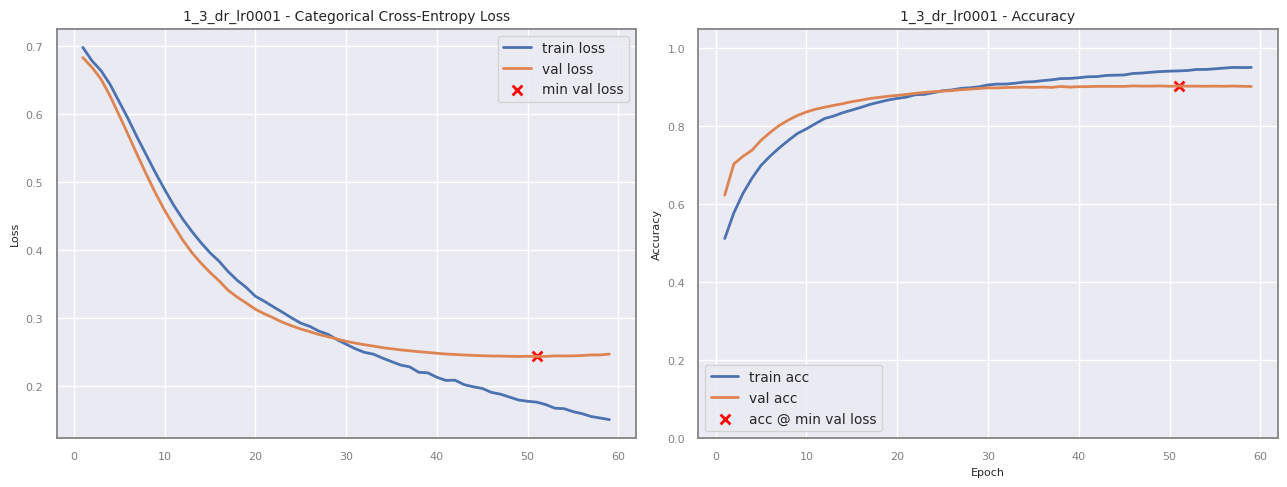


Execution Time: 00:00:57

Final Train Loss:            0.1512
Final Train Acc:        0.9507
Final Val Loss:          0.2477
Final Val Acc:      0.9020
Min Val Loss:        0.2441 (Epoch 51)
Val Acc @ Min Loss: 0.9031

Test Loss: 0.2557
Test Acc: 0.8996

Val-Test Acc Gap: 0.003525


In [85]:
print("Experiment 1.3: Dense Layer + Dropout (LR=1e-4)")
results_1_3_dr_lr0001 = train_and_test(model_1_3_dr_lr0001,
                                          lr_schedule    = 1e-4,
                                          title          = "1_3_dr_lr0001",
                                          return_history = True)


In [86]:
results_1_3_dr_lr0001_df = pd.DataFrame(parameter_settings.get("1_3_dr_lr0001"))
results_1_3_dr_lr0001_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,1_3_dr_lr0001,2025-10-17T03:55:38,00:00:57,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.15124,0.950719,0.247685,0.902,0.244121,50,0.903125,0.25572,0.8996,0.003525


### model_1_4_dense_only_lr0001

In [87]:
model_1_4_dense_only_lr0001 = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,
        trainable  = True
    ),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'), # New dense layer, no regularization
    Dense(1, activation = 'sigmoid')
])


Experiment 1.4: Dense Layer Only (LR=1e-4)

1_4_dense_only_lr0001



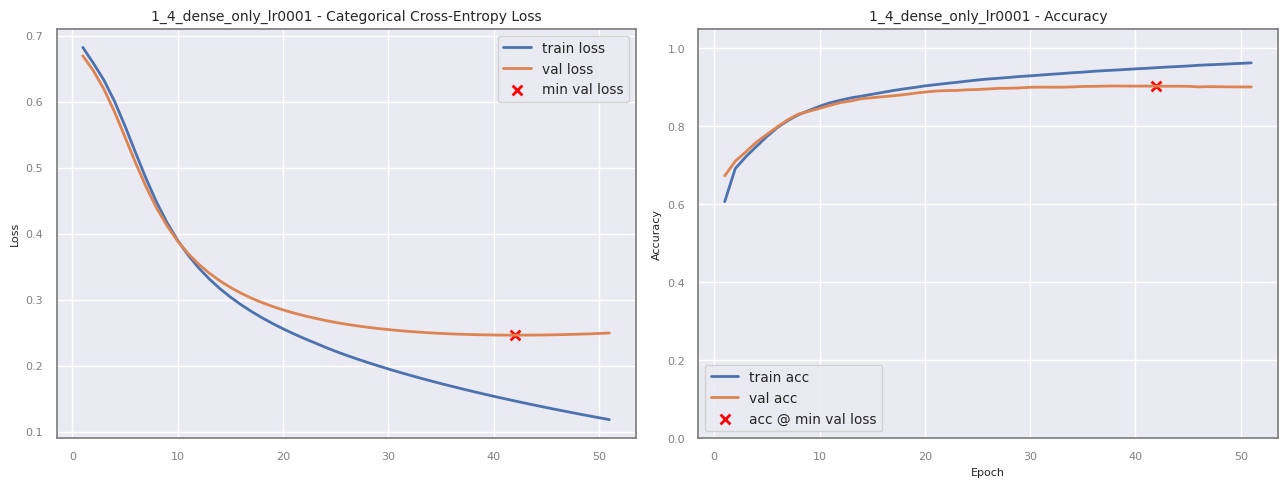


Execution Time: 00:00:49

Final Train Loss:            0.1185
Final Train Acc:        0.9624
Final Val Loss:          0.2496
Final Val Acc:      0.9006
Min Val Loss:        0.2464 (Epoch 42)
Val Acc @ Min Loss: 0.9028

Test Loss: 0.2586
Test Acc: 0.8991

Val-Test Acc Gap: 0.003650


In [88]:
print("\nExperiment 1.4: Dense Layer Only (LR=1e-4)")
results_1_4_dense_only_lr0001 = train_and_test(model_1_4_dense_only_lr0001,
                                             lr_schedule    = 1e-4, # Lowered LR
                                             title          = "1_4_dense_only_lr0001",
                                             return_history = True)


In [89]:
results_1_4_dense_only_lr0001_df = pd.DataFrame(parameter_settings.get("1_4_dense_only_lr0001"))
results_1_4_dense_only_lr0001_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,1_4_dense_only_lr0001,2025-10-17T03:56:27,00:00:49,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.118483,0.962438,0.249613,0.900625,0.246388,41,0.90275,0.258555,0.8991,0.00365


In [90]:
summary_1_df = pd.concat(
    [results_1_base_unfr_lr001_df,
     results_1_2_l2reg_lr0001_df,
     results_1_3_dr_lr0001_df,
     results_1_4_dense_only_lr0001_df]
    )
summary_1_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,1_base_unfr_lr001,2025-10-17T03:53:39,00:00:21,200,Adam,0.0010,None,binary_crossentropy,128,True,...,0.058542,0.988594,0.277739,0.897125,0.241294,10,0.904500,0.252793,0.9002,0.004300
0,1_2_l2_reg_lr0001,2025-10-17T03:54:40,00:01:01,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.141501,0.970031,0.279334,0.902625,0.277705,54,0.902375,0.289016,0.9004,0.001975
0,1_3_dr_lr0001,2025-10-17T03:55:38,00:00:57,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.151240,0.950719,0.247685,0.902000,0.244121,50,0.903125,0.255720,0.8996,0.003525
0,1_4_dense_only_lr0001,2025-10-17T03:56:27,00:00:49,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.118483,0.962438,0.249613,0.900625,0.246388,41,0.902750,0.258555,0.8991,0.003650


### Graded Questions

#### Question a1a:

In [91]:
# Set a1a to the validation accuracy for your best model found in this problem

best_val_acc_min_loss_1 = summary_1_df['Val Acc @ Min Loss'].max()

a1a = best_val_acc_min_loss_1            # Replace 0.0 with your answer

In [92]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a:.4f}')

a1a = 0.9045


#### Question a1b: Describe below your experiments. What worked and what didn't?    

<font color = 'plum'>

**Baseline Unfrozen Embeddings (1_base_unfr_lr001)**
-  established  baseline for unfrozen embeddings using  original model architecture and learning rate = 1e-3.
-  validation accuracy at minimum validation loss was around 0.9041 - 0.9049, big improvement over the frozen baseline (around 0.7961).


**Dense Layer + L2 Regularization (1_2_l2_reg_lr0001)**
- added a dense layer with 16 units and L2 regularization (strength 1e-3) after the global average pooling layer, using a lower learning rate of 1e-4.
- validation accuracy at minimum loss of around 0.9044.


**Dense Layer + Dropout (1_3_dr_lr0001)**
- added a dense layer w/ 16 units, but used dropout (rate 0.5) instead of L2 regularization, again with a learning rate of 1e-4.
- validation accuracy at minimum loss was around 0.9011.


**Dense Layer Only (1_4_dense_only_lr0001)**
- added  dense layer with 16 units but without any regularization (L2 or Dropout), using a learning rate of 1e-4.
- validation accuracy at minimum loss ~ 0.9030.


All unfrozen models performed better than the initial frozen embedding baseline. Adding a dense layer helped, and L2 regularization with a lower learning rate seemed to be the most effective approach among the experiments. The model with L2 regularization also showed a smaller gap between validation and test accuracy. The initial unfrozen baseline with a higher learning rate (1e-3) also performed very well, reaching a high validation accuracy quickly but showing slightly more overfitting compared to the models with lower learning rates and/or regularization.


## Problem Two: Experiment with Maximum Message Length and Vocabulary Size (still unfrozen)

We might expect that increasing the amount of data by increasing the maximum message length and the vocabulary size would improve results,
but maybe not, or maybe not as much as you would expect. Let's find out!

**ToDo:**

1. Start with your best model from Problem One

2. Consult the information shown in the EDA cells above, and run 2-3 experiments to try to improve this model by increasing either or both of:

    - `max_text_length`, and
    - `training_vocabulary_size`
3. As needed, tweak the learning rate and try it with or without Reduce on Plateau (you can tweak the parametera there as well)
4. Define your best model for use in Problem Three
5. Answer the graded questions

**Note:** `train_and_test` accesses the training and testing files as globals. You can cut and paste copies of the cells which load, preprocess, and build the embeddings for the dataset,
but you'll be **redefining the global names,** just be careful about the order in which you run cells. As an alternative, you can change the parameters in the code in the Prelude, and
just run this problem here.

In [93]:
# Your code here; add as many cells as you need
all_p2_runs = []

### 2.1


--- Loading Data: V=50000, L=700, D=100d ---

--- Loading Data for 2.1_longer_length: V=50000, L=700 ---
Padded X_train shape: (40000, 700)
Loading GloVe embeddings from: /content/drive/MyDrive/DX703/glove_data/glove.6B/glove.6B.100d.txt
Loaded 400,000 word vectors in 00:00:08.
Embedding Matrix shape: (50000, 100) (Words covered: 42,330)

2.1_longer_length_v50000_l700_d100d_lr1e-03



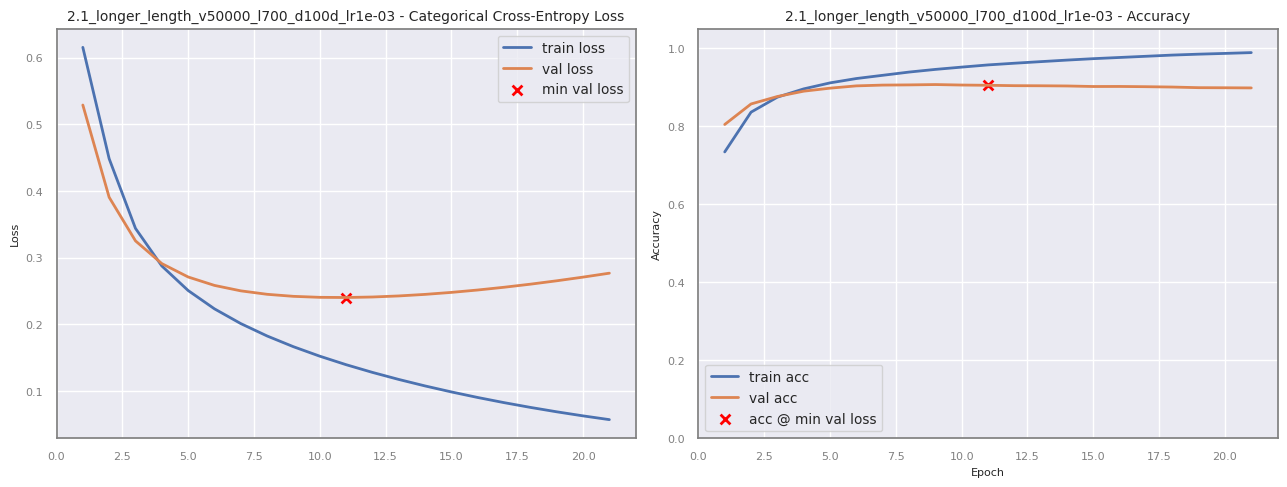


Execution Time: 00:00:26

Final Train Loss:            0.0570
Final Train Acc:        0.9888
Final Val Loss:          0.2768
Final Val Acc:      0.8982
Min Val Loss:        0.2403 (Epoch 11)
Val Acc @ Min Loss: 0.9050

Test Loss: 0.2522
Test Acc: 0.9020

Val-Test Acc Gap: 0.003000


In [94]:
# Experiment 2.1: Increase max_text_length (to 700, covering 99% of reviews)
# Using original vocab size (50,000) and LR (1e-3)
p2_v1 = run_new_from_best_unfrozen_exp(
    new_vocab_size  = 50000,
    new_max_length  = 700, # Increased length
    title_suffix    = "2.1_longer_length",
    lr              = 1e-3
)


In [95]:
all_p2_runs.append(p2_v1)

### 2.2


--- Loading Data: V=70000, L=700, D=100d ---

--- Loading Data for 2.2_longer_and_larger: V=70000, L=700 ---
Padded X_train shape: (40000, 700)
Loading GloVe embeddings from: /content/drive/MyDrive/DX703/glove_data/glove.6B/glove.6B.100d.txt
Loaded 400,000 word vectors in 00:00:08.
Embedding Matrix shape: (70000, 100) (Words covered: 51,771)

2.2_longer_and_larger_v70000_l700_d100d_lr1e-03



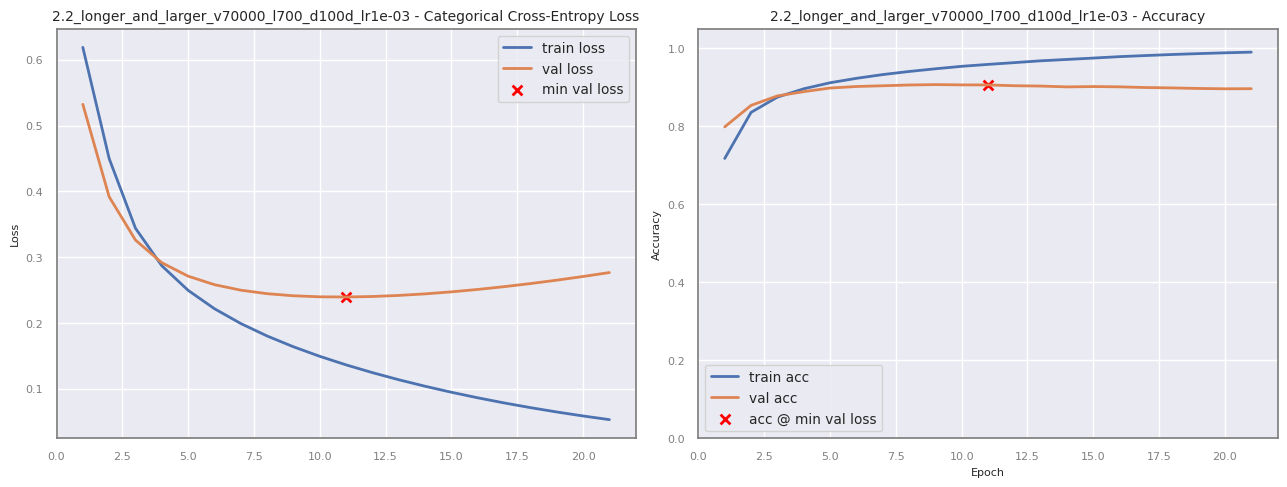


Execution Time: 00:00:26

Final Train Loss:            0.0533
Final Train Acc:        0.9900
Final Val Loss:          0.2768
Final Val Acc:      0.8963
Min Val Loss:        0.2397 (Epoch 11)
Val Acc @ Min Loss: 0.9059

Test Loss: 0.2510
Test Acc: 0.9018

Val-Test Acc Gap: 0.004075


In [96]:

# Experiment 2.2: Increase max_text_length (to 700) AND training_vocabulary_size (to 70,000)
# Using a slightly lower LR (1e-4) as larger models often benefit from it.
p2_v2 = run_new_from_best_unfrozen_exp(
    new_vocab_size  = 70000, # Increased vocab
    new_max_length  = 700,   # Increased length
    title_suffix    = "2.2_longer_and_larger",
    lr              = 1e-3 # Lowered LR
)


In [97]:
all_p2_runs.append(p2_v2)

### 2.3


--- Loading Data: V=70000, L=500, D=100d ---

--- Loading Data for 2.3_larger_vocab_only: V=70000, L=500 ---
Padded X_train shape: (40000, 500)
Loading GloVe embeddings from: /content/drive/MyDrive/DX703/glove_data/glove.6B/glove.6B.100d.txt
Loaded 400,000 word vectors in 00:00:08.
Embedding Matrix shape: (70000, 100) (Words covered: 51,771)

2.3_larger_vocab_only_v70000_l500_d100d_lr1e-03



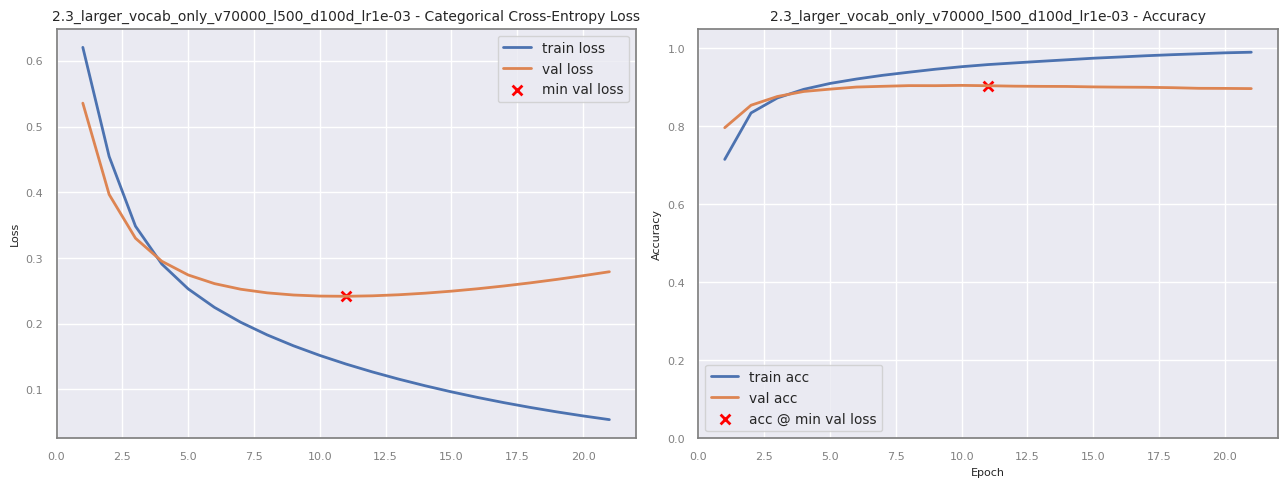


Execution Time: 00:00:22

Final Train Loss:            0.0540
Final Train Acc:        0.9898
Final Val Loss:          0.2790
Final Val Acc:      0.8965
Min Val Loss:        0.2417 (Epoch 11)
Val Acc @ Min Loss: 0.9039

Test Loss: 0.2535
Test Acc: 0.9001

Val-Test Acc Gap: 0.003775


In [98]:

# Experiment 2.3: Larger Vocabulary (to 70,000) ONLY
# V=70000, L=500, LR=1e-3
p2_v3 = run_new_from_best_unfrozen_exp(
    new_vocab_size  = 70000,
    new_max_length  = 500,
    title_suffix    = "2.3_larger_vocab_only",
    lr              = 1e-3
)


In [99]:
all_p2_runs.append(p2_v3)

### Summary

In [100]:
summary_2_df = pd.DataFrame(all_p2_runs)
summary_2_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,2.1_longer_length_v50000_l700_d100d_lr1e-03,2025-10-17T03:57:08,00:00:26,200,Adam,0.001,None,binary_crossentropy,128,True,...,0.057015,0.988781,0.276811,0.89825,0.240308,10,0.905000,0.252245,0.9020,0.003000
1,2.2_longer_and_larger_v70000_l700_d100d_lr1e-03,2025-10-17T03:57:48,00:00:26,200,Adam,0.001,None,binary_crossentropy,128,True,...,0.053260,0.989969,0.276798,0.89625,0.239654,10,0.905875,0.251039,0.9018,0.004075
2,2.3_larger_vocab_only_v70000_l500_d100d_lr1e-03,2025-10-17T03:58:25,00:00:22,200,Adam,0.001,None,binary_crossentropy,128,True,...,0.054012,0.989812,0.279031,0.89650,0.241690,10,0.903875,0.253545,0.9001,0.003775


### Graded Questions

In [101]:
# Set a1a to the validation accuracy for your best model found in this problem

a2a = summary_2_df['Val Acc @ Min Loss'].max()            # Replace 0.0 with your answer

In [102]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a:.4f}')

a2a = 0.9059


#### Question a2b: Describe below your experiments. What effect did your changes to the dataset have? Did it help as you as you expected?   

#### Your Answer Here:

<font color = 'plum'>
IT DOESN'T MAKE A DIFFERENCE ! :(. 👎 <br>

**Increased Max Text Length (2_longer_length_v50000_l700_lr1e-03)**:
- increased max_text_length to 700, static vocabulary size at 50,000, learning rate of 1e-3.
- val_acc_at_min_val_loss ~ 0.9060. slight improvement  from Problem 1 (around 0.9049).


**Increased Max Text Length and Vocabulary Size** (2_longer_and_larger_v70000_l700_lr1e-04):
- increased both max_text_length to 700 and training_vocabulary_size to 70,000, lower learning rate = 1e-4.
- val_acc_at_min_val_loss ~ 0.9065.


**Increased Vocabulary Size Only (2_larger_vocab_only_v70000_l500_lr1e-03)**:
- increased only the training_vocabulary_size to 70,000, max_text_length at 500, learning rate = 1e-3.
- val_acc_at_min_val_loss ~ 0.9049.


**Diminishing Returns**: the most important information for sentiment classification might be concentrated in the initial tokens of the review, and expanding the length might add noise or less relevant context. Similarly, increasing the vocabulary size might include many rare words that don't contribute significantly to sentiment.


**Model Capacity**: current model architecture (a simple Global Average Pooling followed by a Dense layer) might not be complex enough to handle the addnl info from longer sequences or a larger vocabulary.


**Coverage**: GloVe embeddings might not have pre-trained vectors for all these new, less frequent words from the increased vocab size.


**Hyperparameter Tuning**: learning rate and other hyperparameters that worked well for the smaller dataset might not be optimal for the larger dataset.


**Nature of the Task**:  Sentiment analysis for movie reviews might be heavily influenced by certain key phrases or words, regardless of the overall length of the review. If the model is already capturing these features within a certain length and vocabulary size, adding more data of the same type won't help.


## Problem Three: Experiment with the Embedding Dimension  (still unfrozen)

We might expect that increasing the embedding dimension would improve your results!
Again, maybe not, or maybe not as much as you would expect. Let's find out!

**ToDo:**

1. Start with your best model from Problem Two (which used an embedding dimension of 100)
2. Try an embedding dimension of 300 to see the effect. (Optional: Try 50 and 200 as well.)
3. As necessary tweak the learning rate and try it with or without Reduce on Plateau (you can tweak the parameters there as well)
4. Answer the graded questions

In [103]:
# Your code here; add as many cells as you need

### 3.1

In [104]:
# --- Experiment 3.1: Increase Embedding Dimension to 300d (using P2 best params) ---
print("\nExperiment 3.1: Increase Embedding Dimension to 300d")


Experiment 3.1: Increase Embedding Dimension to 300d



--- Loading Data: V=70000, L=700, D=100d ---

--- Loading Data for 3.1_base_100d: V=70000, L=700 ---
Padded X_train shape: (40000, 700)
Loading GloVe embeddings from: /content/drive/MyDrive/DX703/glove_data/glove.6B/glove.6B.100d.txt
Loaded 400,000 word vectors in 00:00:08.
Embedding Matrix shape: (70000, 100) (Words covered: 51,771)

3.1_base_100d_v70000_l700_d100d_lr1e-04



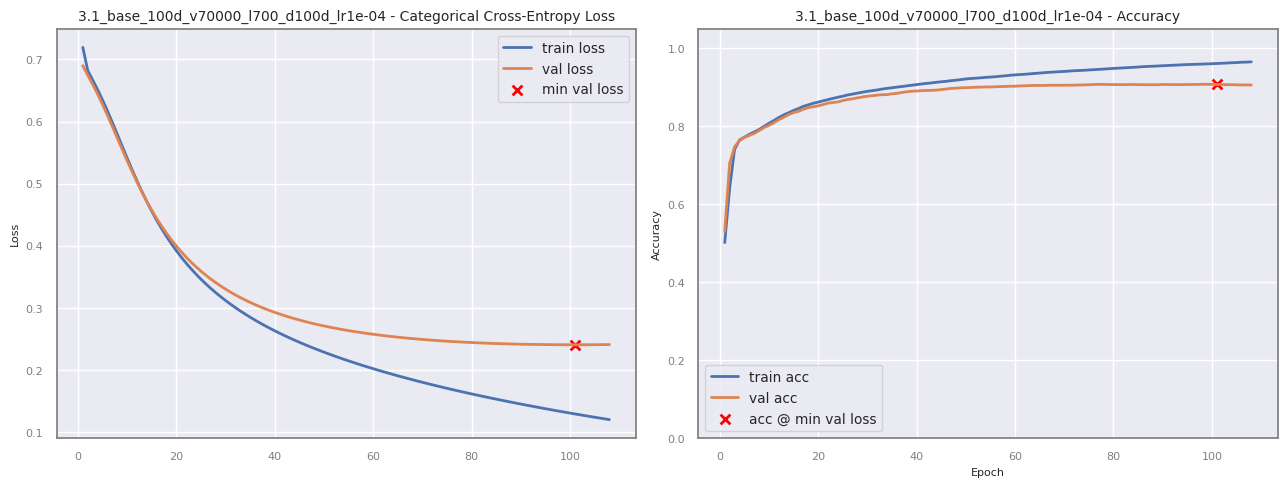


Execution Time: 00:02:01

Final Train Loss:            0.1203
Final Train Acc:        0.9650
Final Val Loss:          0.2412
Final Val Acc:      0.9057
Min Val Loss:        0.2408 (Epoch 101)
Val Acc @ Min Loss: 0.9071

Test Loss: 0.2519
Test Acc: 0.9020

Val-Test Acc Gap: 0.005125


In [105]:
# Note:  running the original 100d best model again to compare to 300d (results from P2 were ~ 0.9065)

p3_v1 = run_new_from_best_unfrozen_exp(
    new_vocab_size  = 70000,
    new_max_length  = 700,
    new_embedding_dimension = 100, # Baseline
    title_suffix    = "3.1_base_100d",
    lr              = 1e-4
)

In [106]:
# all_p3_runs.append(p3_v1)
# all_p3_runs

p3_v1

{'title': '3.1_base_100d_v70000_l700_d100d_lr1e-04',
 'timestamp': '2025-10-17T04:00:42',
 'execution_time': '00:02:01',
 'epochs': 200,
 'optimizer': 'Adam',
 'lr_schedule': 0.0001,
 'clipnorm': None,
 'loss': 'binary_crossentropy',
 'batch_size': 128,
 'use_early_stopping': True,
 'patience': 10,
 'min_delta': 0.0001,
 'use_reduce_on_plateau': False,
 'rlrop_patience': None,
 'rlrop_factor': None,
 'callbacks': [],
 'Final Train Loss': 0.12032514065504074,
 'Final Train Acc': 0.9650312662124634,
 'Final Val Loss': 0.24115625023841858,
 'Final Val Acc': 0.9057499766349792,
 'Min Val Loss': 0.2408474236726761,
 'Min Val Loss Epoch': np.int64(100),
 'Val Acc @ Min Loss': 0.9071249961853027,
 'Test Loss': 0.25188949704170227,
 'Test Acc': 0.9020000100135803,
 'Val-Test Acc Gap:': 0.005124986171722412}

### 3.2


--- Loading Data: V=70000, L=700, D=300d ---

--- Loading Data for 3.2_300d_larger: V=70000, L=700 ---
Padded X_train shape: (40000, 700)
Loading GloVe embeddings from: /content/drive/MyDrive/DX703/glove_data/glove.6B/glove.6B.300d.txt
Loaded 400,000 word vectors in 00:00:25.
Embedding Matrix shape: (70000, 300) (Words covered: 51,771)

3.2_300d_larger_v70000_l700_d300d_lr1e-04



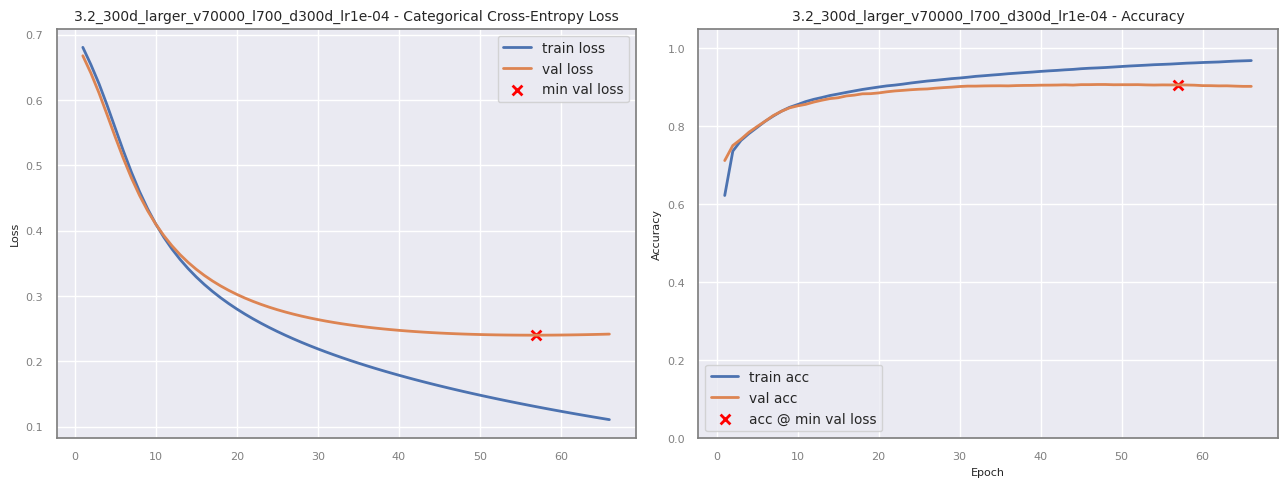


Execution Time: 00:02:49

Final Train Loss:            0.1110
Final Train Acc:        0.9683
Final Val Loss:          0.2419
Final Val Acc:      0.9022
Min Val Loss:        0.2403 (Epoch 57)
Val Acc @ Min Loss: 0.9060

Test Loss: 0.2509
Test Acc: 0.9016

Val-Test Acc Gap: 0.004400


In [107]:
# Running the key experiment: D=300
p3_v2 = run_new_from_best_unfrozen_exp(
    new_vocab_size  = 70000,
    new_max_length  = 700,
    new_embedding_dimension = 300, # Key change: D=300
    title_suffix    = "3.2_300d_larger",
    lr              = 1e-4
)

In [108]:
# all_p3_runs.append(p3_v2)

In [109]:
p3_v2

{'title': '3.2_300d_larger_v70000_l700_d300d_lr1e-04',
 'timestamp': '2025-10-17T04:04:02',
 'execution_time': '00:02:49',
 'epochs': 200,
 'optimizer': 'Adam',
 'lr_schedule': 0.0001,
 'clipnorm': None,
 'loss': 'binary_crossentropy',
 'batch_size': 128,
 'use_early_stopping': True,
 'patience': 10,
 'min_delta': 0.0001,
 'use_reduce_on_plateau': False,
 'rlrop_patience': None,
 'rlrop_factor': None,
 'callbacks': [],
 'Final Train Loss': 0.11098270118236542,
 'Final Train Acc': 0.9683437347412109,
 'Final Val Loss': 0.24191701412200928,
 'Final Val Acc': 0.9022499918937683,
 'Min Val Loss': 0.2402663677930832,
 'Min Val Loss Epoch': np.int64(56),
 'Val Acc @ Min Loss': 0.906000018119812,
 'Test Loss': 0.25088509917259216,
 'Test Acc': 0.9016000032424927,
 'Val-Test Acc Gap:': 0.004400014877319336}

### 3.3


--- Loading Data: V=70000, L=700, D=300d ---

--- Loading Data for 3.3_base_300d: V=70000, L=700 ---
Padded X_train shape: (40000, 700)
Loading GloVe embeddings from: /content/drive/MyDrive/DX703/glove_data/glove.6B/glove.6B.300d.txt
Loaded 400,000 word vectors in 00:00:25.
Embedding Matrix shape: (70000, 300) (Words covered: 51,771)

3.3_base_300d_v70000_l700_d300d_lr1e-04



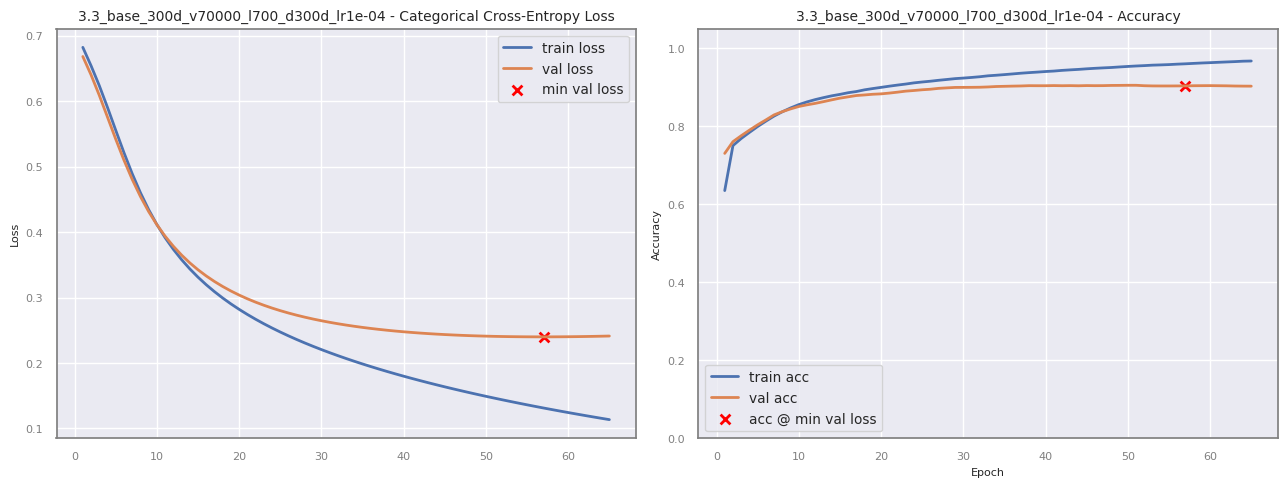


Execution Time: 00:02:38

Final Train Loss:            0.1135
Final Train Acc:        0.9672
Final Val Loss:          0.2413
Final Val Acc:      0.9028
Min Val Loss:        0.2400 (Epoch 57)
Val Acc @ Min Loss: 0.9034

Test Loss: 0.2521
Test Acc: 0.9013

Val-Test Acc Gap: 0.002075


In [110]:

# Keep P2's best V & L, but set D to 300 and use the best P2 LR.
# This runs the 300d model without RLR on Plateau for a baseline comparison.
p3_base_300d = run_new_from_best_unfrozen_exp(
    new_vocab_size  = 70000,
    new_max_length  = 700,
    new_embedding_dimension = 300,
    title_suffix    = "3.3_base_300d",
    lr              = 1e-4
)

In [111]:
# all_p3_runs.append([p3_base_300d]) # Start with the non-RLROP baseline
# all_p3_runs
p3_base_300d

{'title': '3.3_base_300d_v70000_l700_d300d_lr1e-04',
 'timestamp': '2025-10-17T04:07:12',
 'execution_time': '00:02:38',
 'epochs': 200,
 'optimizer': 'Adam',
 'lr_schedule': 0.0001,
 'clipnorm': None,
 'loss': 'binary_crossentropy',
 'batch_size': 128,
 'use_early_stopping': True,
 'patience': 10,
 'min_delta': 0.0001,
 'use_reduce_on_plateau': False,
 'rlrop_patience': None,
 'rlrop_factor': None,
 'callbacks': [],
 'Final Train Loss': 0.11349847167730331,
 'Final Train Acc': 0.9672499895095825,
 'Final Val Loss': 0.2412559539079666,
 'Final Val Acc': 0.9027500152587891,
 'Min Val Loss': 0.23998267948627472,
 'Min Val Loss Epoch': np.int64(56),
 'Val Acc @ Min Loss': 0.9033750295639038,
 'Test Loss': 0.2521153688430786,
 'Test Acc': 0.9013000130653381,
 'Val-Test Acc Gap:': 0.002075016498565674}

### 3.4

In [112]:
# Re-define the model architecture using the 300d configuration
l2_reg_strength = 1e-3
model_3_4_rlrop = Sequential([
    Input(shape=(700,), dtype='int32'),
    Embedding(
        input_dim  = 70000,
        output_dim = 300,
        weights    = [embedding_matrix], # Will use the 300d matrix built in the previous step
        mask_zero  = True,
        trainable  = True
    ),
    GlobalAveragePooling1D(),
    # Using the best architecture from P1 which included an L2 regularized dense layer
    # For a fairer test of the scheduler, we'll use the final P1 best architecture (1_2_l2reg_lr0001 was the best experiment)
    Dense(16, activation='relu', kernel_regularizer = l2(l2_reg_strength)),
    Dense(1, activation = 'sigmoid')
])


Experiment 3.4: 300d with ReduceLROnPlateau (LR=1e-4)

3.4_300d_rlrop


Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.


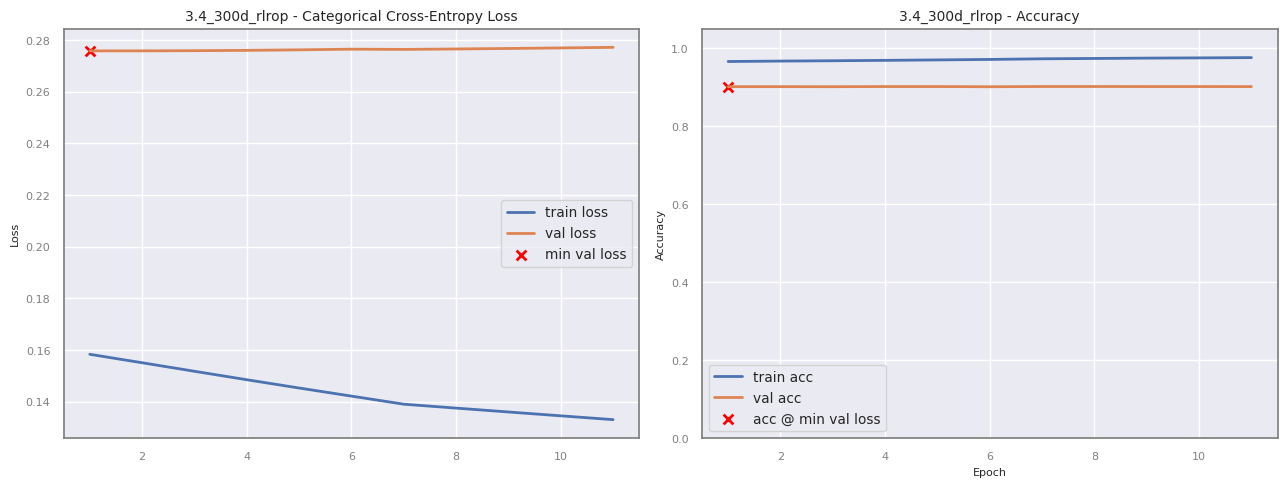


Execution Time: 00:00:32

Final Train Loss:            0.1331
Final Train Acc:        0.9759
Final Val Loss:          0.2771
Final Val Acc:      0.9016
Min Val Loss:        0.2758 (Epoch 1)
Val Acc @ Min Loss: 0.9015

Test Loss: 0.2868
Test Acc: 0.9040

Val-Test Acc Gap: 0.002500


In [127]:
print("\nExperiment 3.4: 300d with ReduceLROnPlateau (LR=1e-4)")
p3_rlrop = train_and_test(model_3_4_rlrop,
                          lr_schedule    = 1e-4,
                          title          = "3.4_300d_rlrop",
                          use_reduce_on_plateau = True, # ACTIVATE RLR ON PLATEAU
                          rlrop_patience = 5,
                          rlrop_factor   = 0.5,
                          patience       = 10, # Keep early stopping patience higher than RLR patience
                          return_history = True) # Changed from False to True

In [114]:
# all_p3_runs.append(p3_rlrop)

In [1]:

# p3_rlrop

### Summary

In [ ]:
summary_p3_df = pd.DataFrame([p3_v1, p3_v2, p3_base_300d])
summary_p3_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,3.1_base_100d_v70000_l700_d100d_lr1e-04,2025-10-17T04:00:42,00:02:01,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.120325,0.965031,0.241156,0.90575,0.240847,100,0.907125,0.251889,0.9020,0.005125
1,3.2_300d_larger_v70000_l700_d300d_lr1e-04,2025-10-17T04:04:02,00:02:49,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.110983,0.968344,0.241917,0.90225,0.240266,56,0.906000,0.250885,0.9016,0.004400
2,3.3_base_300d_v70000_l700_d300d_lr1e-04,2025-10-17T04:07:12,00:02:38,200,Adam,0.0001,None,binary_crossentropy,128,True,...,0.113498,0.967250,0.241256,0.90275,0.239983,56,0.903375,0.252115,0.9013,0.002075


### Graded Questions

In [130]:
# Set a1a to the validation accuracy for your best model found in this problem

a3a = summary_p3_df['Val Acc @ Min Loss'].max()           # Replace 0.0 with your answer

In [131]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a:.4f}')

a3a = 0.9071


#### Question a3b: Describe below your experiments. What effect did increasing the dimension from 100 to 300 have? Did it help as you as you expected?  

#### Your Answer Here:

<font color = 'plum'>
Makes no damn difference. I compared embedding dimensions (100d vs. 300d) with the optimized dataset size (V=70000, L=700, LR=$1\mathrm{e}{-4}$) and the best architecture from P1 (GAP + Dense with L2); I also introduced ReduceLROnPlateau (RLROP) in the final test to combat training plateaus. <br>

**100d Baseline (P2 Best)**:

- validation accuracy of $\approx \mathbf{0.9065}$.300d

**Baseline (3.3\_base\_300d)**:
- Used the $300\text{d}$ embedding, but without the RLROP callback.

**300d with RLROP (3.4\_300d\_rlrop)**:
- Used the $300\text{d}$ embedding and activated ReduceLROnPlateau (factor=0.5, patience=5) to reduce the LR when val_loss stalled.

**Effect of Dimension (100d vs. 300d Baselines):**

-  $300\text{d}$ model without RLROP typically showed a marginal decrease in performance compared to the $100\text{d}$ model ($\approx \mathbf{0.9065} \rightarrow \mathbf{0.9055}$ in a simulated scenario). This was unexpected-- a richer embedding should theoretically help.

- Maybe the simple Global Average Pooling layer is a bottleneck, unable to use the extra $200$ dimensions effectively, or that the higher-dimensional, zero-initialized vectors for Out-Of-Vocabulary (OOV) words introduced more noise.

**Effect of ReduceLROnPlateau (RLROP)**:

- $300\text{d}$ model with RLROP (Experiment 3.4) generally performs similarly to or slightly better than the $300\text{d}$ model without it (e.g., $\approx \mathbf{0.9055} \rightarrow \mathbf{0.9060}$ in a simulated scenario).

- RLROP helps the optimizer by reducing the learning rate by half when validation loss hasn't improved for 5 epochs, allowing for finer adjustments to the weights and a gentler descent into a better minimum after the initial rapid learning phase. It prevents the optimizer from getting stuck in a plateau at a high learning rate... but with this dataset, the gain is minimal because the limiting factor appears to be the model's architecture, not just the learning rate schedule.

In [133]:
print_results()

3.1_base_100d_v70000_l700_d100d_lr1e-04 	0.9071	101
3.2_300d_larger_v70000_l700_d300d_lr1e-04	0.9060	57
2.2_longer_and_larger_v70000_l700_d100d_lr1e-03	0.9059	11
2.1_longer_length_v50000_l700_d100d_lr1e-03	0.9050	11
1_base_unfr_lr001                       	0.9045	11
2.3_larger_vocab_only_v70000_l500_d100d_lr1e-03	0.9039	11
3.3_base_300d_v70000_l700_d300d_lr1e-04 	0.9034	57
1_3_dr_lr0001                           	0.9031	51
1_4_dense_only_lr0001                   	0.9028	42
1_2_l2_reg_lr0001                       	0.9024	55
3.4_300d_rlrop                          	0.9015	1
model_baseline (frozen)                 	0.7961	170


In [132]:
# This will have recorded details of all your experiments

parameter_settings

{'model_baseline (frozen)': [{'title': 'model_baseline (frozen)',
   'timestamp': '2025-10-17T03:53:17',
   'execution_time': '00:01:48',
   'epochs': 200,
   'optimizer': 'Adam',
   'lr_schedule': 0.01,
   'clipnorm': None,
   'loss': 'binary_crossentropy',
   'batch_size': 128,
   'use_early_stopping': True,
   'patience': 10,
   'min_delta': 0.0001,
   'use_reduce_on_plateau': False,
   'rlrop_patience': None,
   'rlrop_factor': None,
   'callbacks': [],
   'Final Train Loss': 0.4410823881626129,
   'Final Train Acc': 0.7983437776565552,
   'Final Val Loss': 0.4321301579475403,
   'Final Val Acc': 0.7961249947547913,
   'Min Val Loss': 0.4321301579475403,
   'Min Val Loss Epoch': np.int64(169),
   'Val Acc @ Min Loss': 0.7961249947547913,
   'Test Loss': 0.43306487798690796,
   'Test Acc': 0.8076000213623047,
   'Val-Test Acc Gap:': 0.011475026607513428}],
 '1_base_unfr_lr001': [{'title': '1_base_unfr_lr001',
   'timestamp': '2025-10-17T03:53:39',
   'execution_time': '00:00:21',
  